In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [20, 10]
import pandas as pd
%matplotlib inline

# Purpose

This notebook tests the performance of various types of deep learning models on Station 3 merged dataset to see which model is the best to use for more training-intensive tasks.

# Params Used
Epochs = 100

Learning Rate = 0.001

Dataset = Station 3 Merged Dataset (soil + met data)

Prediction period = 7 days

In [2]:
df_loss = pd.read_csv('station3-results.csv', sep=",", index_col="Model")
df_loss

,Loss,Mean_absolute_error,Val_loss,Val_mean_absolute_error
Model,,,,
Baseline (min-max),0.000412,0.0039,NaN,NaN
Baseline (mean),0.009600,0.0187,NaN,NaN
Single-Step Dense (min-max),0.000258,0.0091,0.000575,0.0148
Single-Step Dense (mean),0.008400,0.0360,0.006500,0.0462
Multi-Step Dense (min-max),0.000648,0.0174,0.003200,0.0313
Multi-Step Dense (mean),0.039600,0.1382,0.057500,0.1793
Multi-Step CNN (min-max),0.000569,0.0159,0.003600,0.0325
Multi-Step CNN (mean),0.034400,0.1268,0.059400,0.1749
Multi-Step RNN LSTM (min-max),0.000112,0.0032,0.000491,0.0066


When looking at loss values, it seems that the models differed in which ones achieved the lowest loss when training. In general, min-max normalization produced lower loss, val loss, mean absolute error, and val mean absolute error values than mean normalization for all the evaluated models (keeping all other values constant). This shows us that min-max normalization, in this scenario, produces better results than mean normalization. When looking at the specific min-max normalized model that performed best, Multi-Step RNN LSTM model had the lowest values. In fact, min-max normalized Multi-Step RNN LSTM had the lowest values for any model across the board.

# Model Accuracy Visualizations

NOTE: The visualizations below are from 3 random examples from the testing dataset. Visualizations of the model's prediicted values against ALL of the test dataset are available when focusing training on the LSTM model (see RNN_Deep_Learning.ipynb and Deep-Learning-Tasks-Analysis.ipynb).

# Baseline Models
### Min-Max Normalization

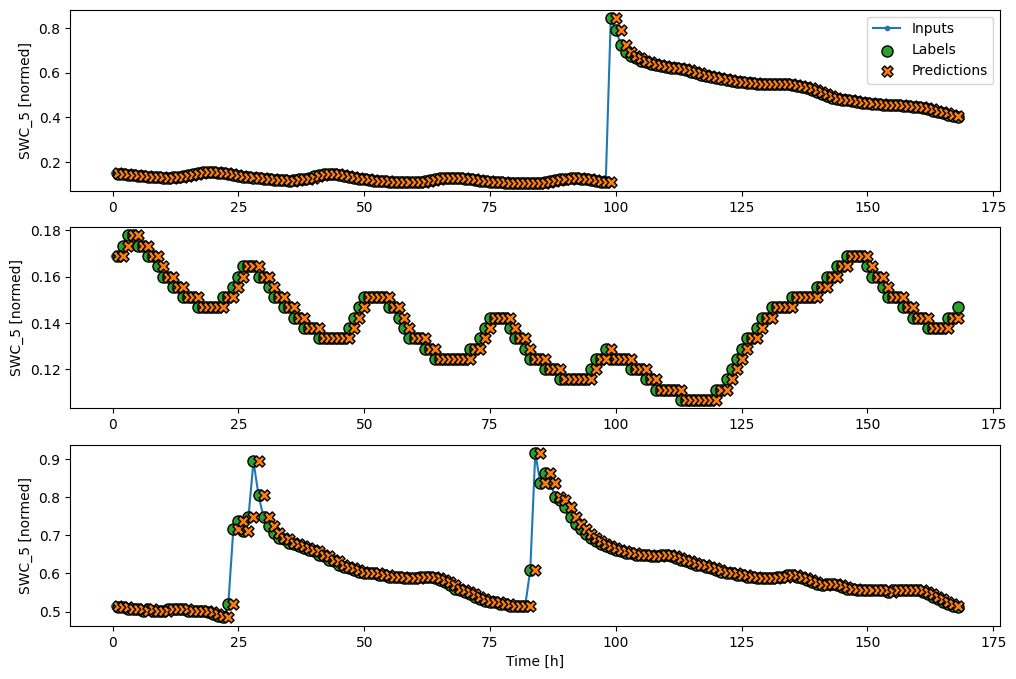

### Mean Normalization

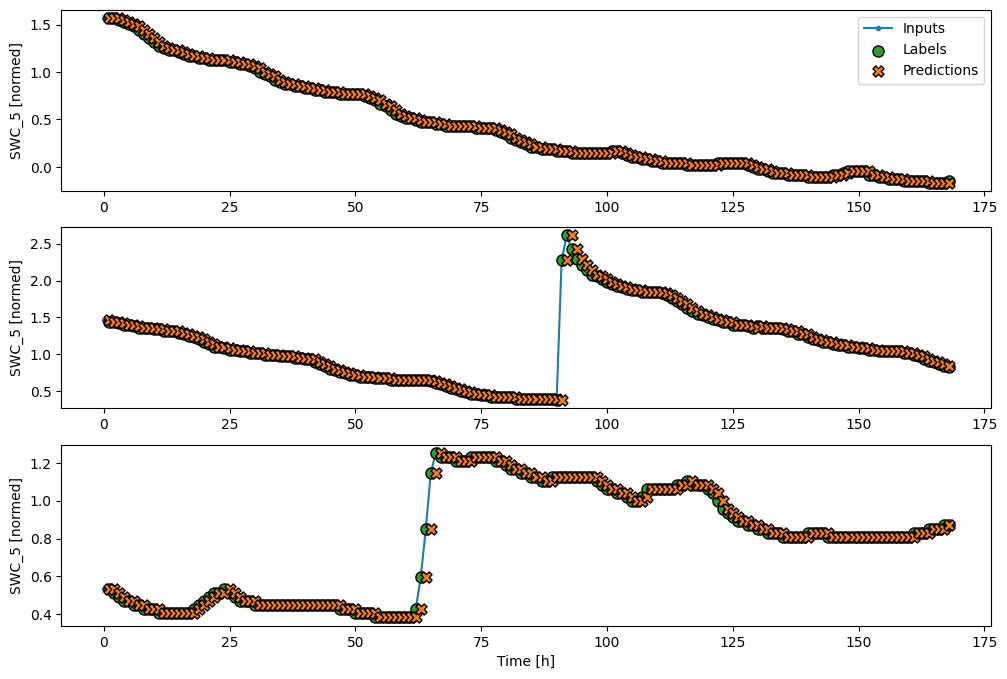

There isn't too much to analyze about the baseline models for both min-max and mean normalizations as the expected behavior is the exact same (prediction == the value at the previous time step). The next models will be more telling at which normalization performed better.

# Multi-Step Dense Models
### Min-Max Normalization

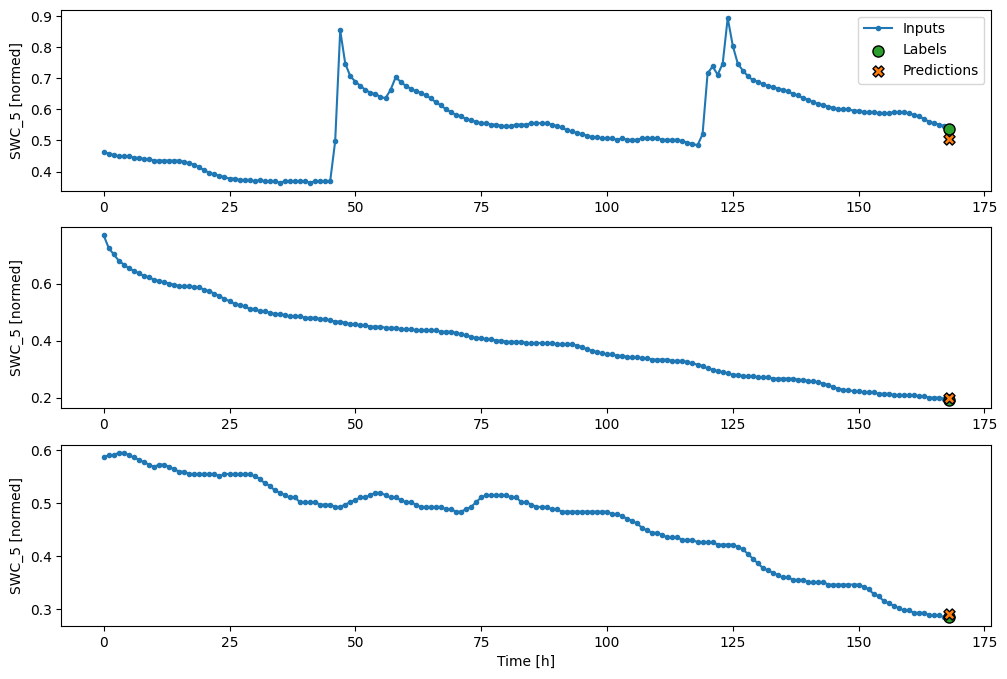

### Mean Normalization

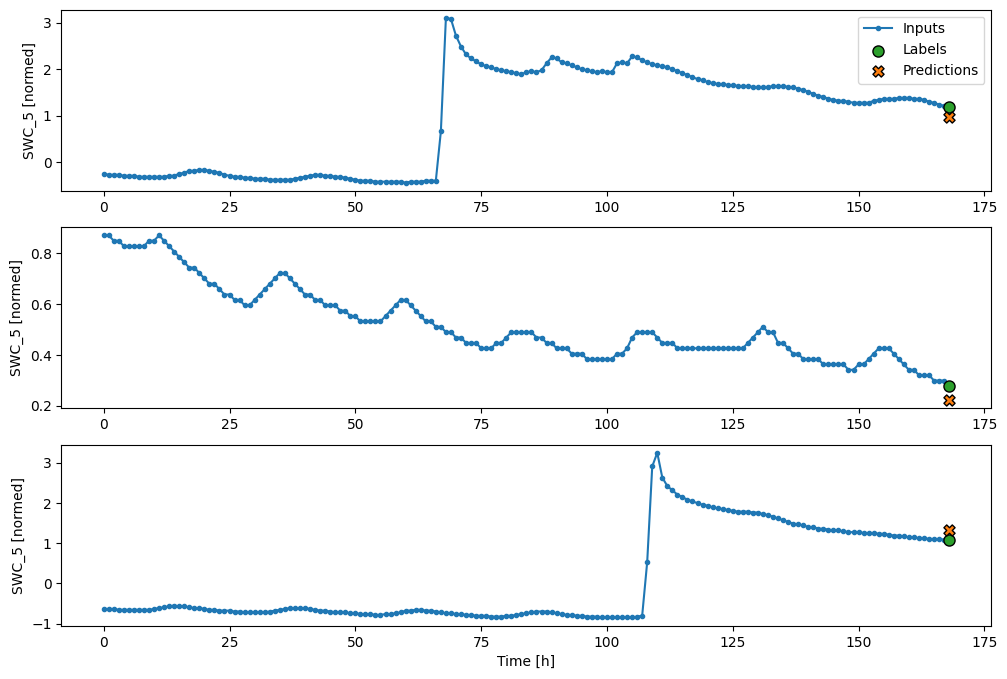

For both min-max and mean normalization, the visualizations show almost identical prediction behavior. Hopefully future models can distinguish the difference better.

# Multi-Step CNN Models
### Min-Max Normalization

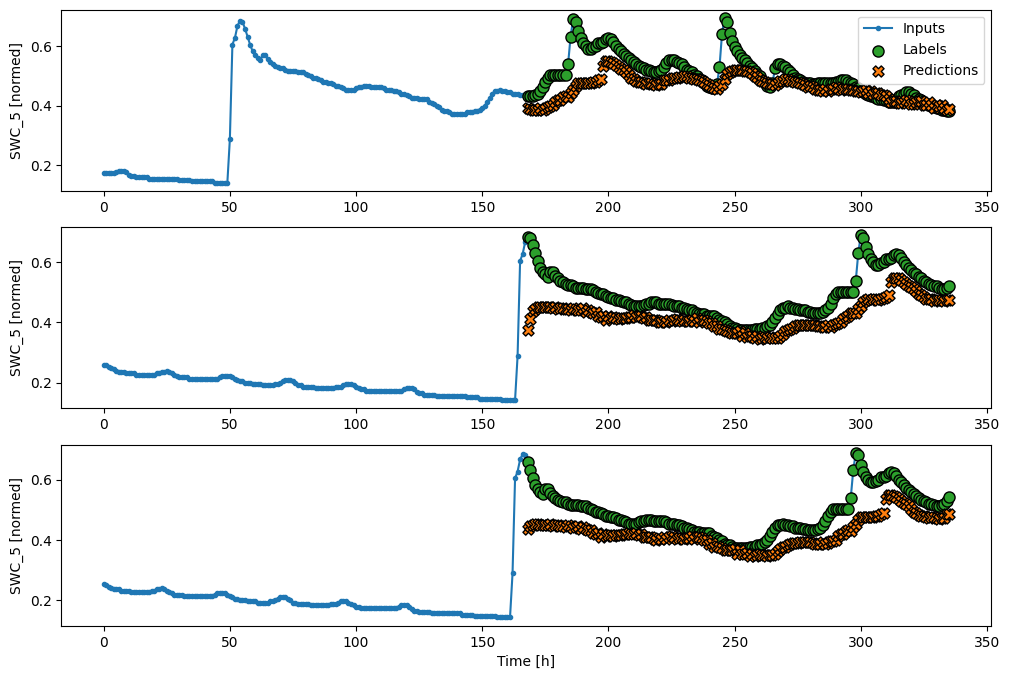

### Mean Normalization

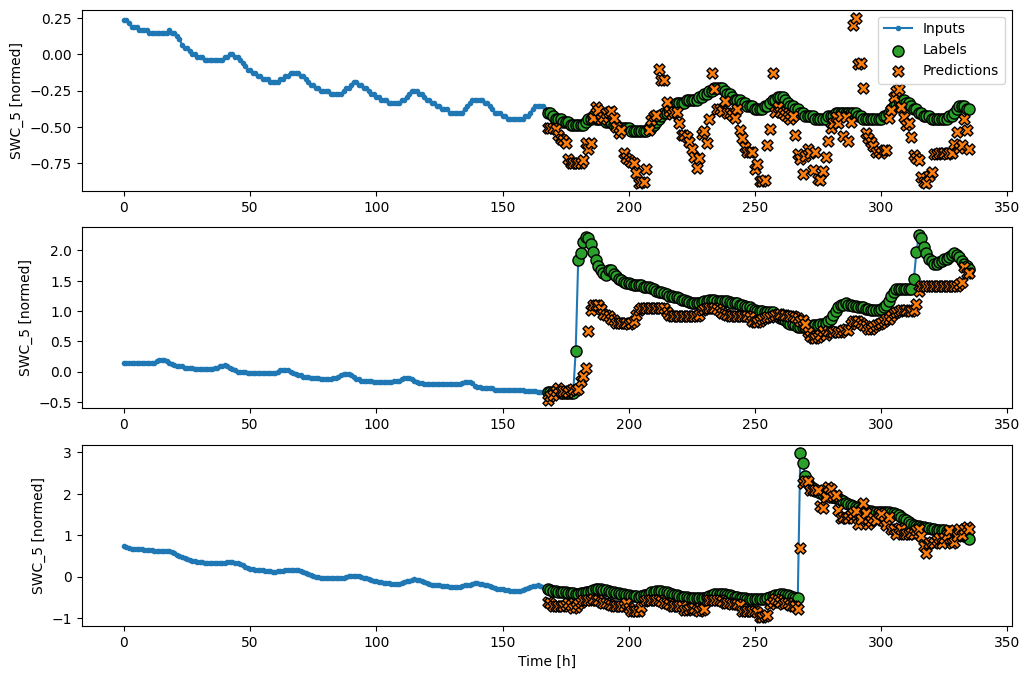

For CNN, the min-max normalization was not bad, as it was able to roughly predict the true labels of the data, but mean normalization was much worse. Both normalizations didn't perform super well for CNN, but overall, min-max normalization predicted trends in the test dataset better.

# Multi-Step RNN Models
### Min-Max Normalization

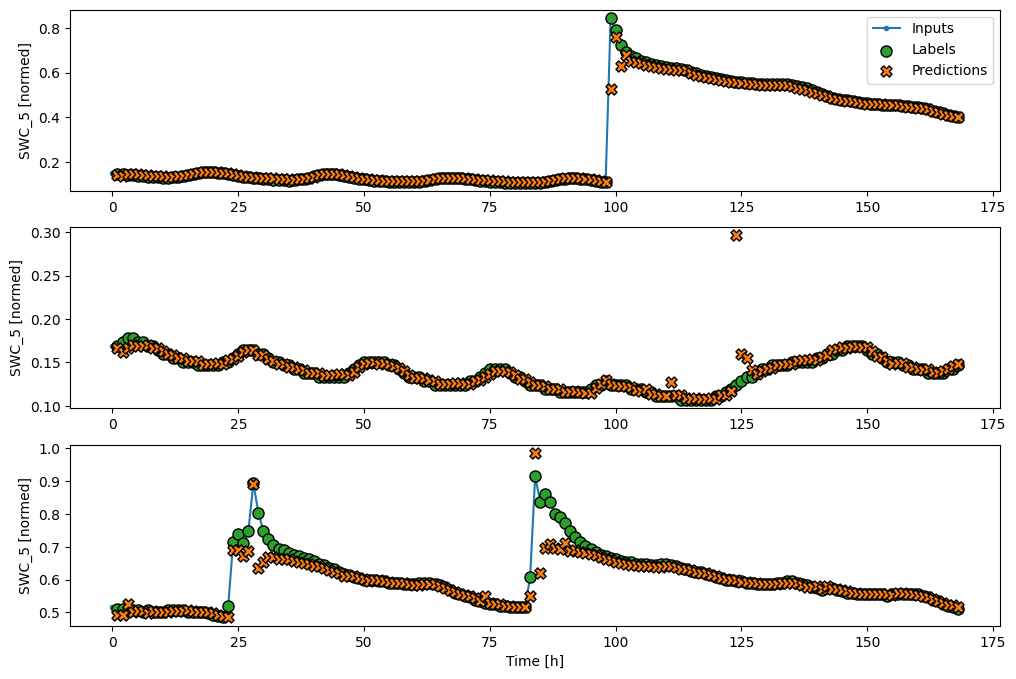

### Mean Normalization

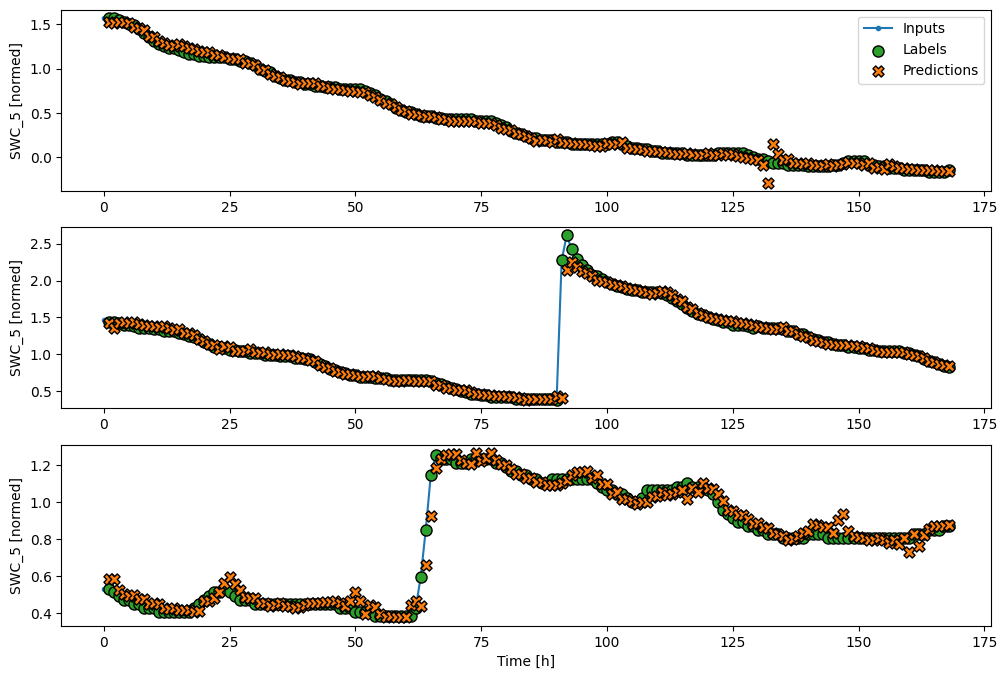

Both normalizations had arguable similar prediction performance when using LSTM model. Although, in the third example for min-max, it had some trouble predicting sudden jumps in SWC_5 values.

# Summary

Overall, min-max normalization tends to prevail as the choice normalization method for this scenario.

Additionally, based on both the loss values and model training visualizations, for min-max normalization method, the LSTM RNN training model seems to be the best for this scenario. It had the lowest loss values (compared to the other models) and its accuracy was corroborated by its visualization, which demonstrated that its predictions could consistently get close to the true labels.

### Best model for this scenario: Multi-step LSTM RNN with Min-Max Normalization